In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

import nibabel as nib
import nilearn.plotting as plotting
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import hcp_utils as hcp


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import tensorflow as tf
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

pd.options.mode.chained_assignment = None  # Hide long warnings

import shap

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter
import math
from tensorflow.keras.layers import BatchNormalization




pixdim[1,2,3] should be non-zero; setting 0 dims to 1
/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = [] # Glasser 2016 which partitions each hemisphere into 180 regions
ca = [] # Cole-Anticevic 2019 which further partitions each hemisphere into ~350 regions
for i in file_list:
    if "mmp" in i:
        mmp_file = np.load(file_path + "/" + i)
        if mmp_file.shape == (3600, 379):
            mmp.append(np.load(file_path + "/" + i))

In [3]:
np.load("parcellations/sub-193845_task-rest_parcellation-ca_timeseries.npy").shape

(3600, 718)

In [4]:
open_access_data = pd.read_csv("Behavioral Data/Behavioral_Data.csv")
restricted_data = pd.read_csv("Behavioral Data/RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

file_path = "parcellations"
file_list = os.listdir(file_path)
mmp = {}
ca = {}
for filename in file_list:
    subject_id = filename[4:10]

    if subject_id.isdigit():
        subject_id = int(subject_id)

        if "mmp" in filename:
            mmp_file = np.load(file_path + "/" + filename)
            if mmp_file.shape == (3600, 379):
                mmp[subject_id] = mmp_file
        if "ca" in filename:
            ca_file = np.load(file_path + "/" + filename)
            if ca_file.shape == (3600, 718):
                ca[subject_id] = ca_file

mmp_data = pd.DataFrame({
    'Subject': list(mmp.keys()),
    'Brain_Data': list(mmp.values())  # (3600, 379) arrays
})


mmp_data = subject_data.merge(mmp_data, on='Subject', how='inner')

In [5]:
mmp_data.head()

,Subject,Release,Acquisition,Gender,Age,3T_Full_MR_Compl,T1_Count,T2_Count,3T_RS-fMRI_Count,3T_RS-fMRI_PctCompl,...,SSAGA_Times_Used_Cocaine,SSAGA_Times_Used_Hallucinogens,SSAGA_Times_Used_Opiates,SSAGA_Times_Used_Sedatives,SSAGA_Times_Used_Stimulants,SSAGA_Mj_Use,SSAGA_Mj_Ab_Dep,SSAGA_Mj_Age_1st_Use,SSAGA_Mj_Times_Used,Brain_Data
0,100610,S900,Q08,M,26-30,True,2,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[2.3968613, 0.33524948, -0.15465337, 1.955118..."
1,102311,S500,Q06,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,"[[-0.13254918, 0.16243707, 0.300286, 0.6371644..."
2,102816,Q3,Q03,F,26-30,True,1,1,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,"[[0.19969857, -0.7308231, -0.46953073, 0.19398..."
3,104416,S900,Q09,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,"[[-0.58722323, -2.054348, -2.3991566, -0.60077..."
4,105923,MEG2,Q07,F,31-35,True,2,2,4,100.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,"[[0.4015313, -0.47590375, -0.058990948, -0.747..."


In [6]:
mmp_data["Handedness_Cat"] = mmp_data["Handedness"].apply(lambda x: 0 if x < 0 else 1)

In [7]:
hand_data = mmp_data[["Subject", "Gender", "Race", "Handedness", "Handedness_Cat"]]
hand_data

,Subject,Gender,Race,Handedness,Handedness_Cat
0,100610,M,White,85,1
1,102311,F,White,10,1
2,102816,F,Black or African Am.,100,1
3,104416,F,Asian/Nat. Hawaiian/Othr Pacific Is.,65,1
4,105923,F,White,35,1
...,...,...,...,...,...
167,943862,M,White,95,1
168,958976,M,White,85,1
169,966975,M,White,40,1
170,971160,M,White,80,1


If using no threshold to classify left- and right-handed:

In [8]:
left_handed = hand_data[hand_data['Handedness'] < 0] 
right_handed = hand_data[hand_data['Handedness'] > 0]

# Handedness statistics
pd.DataFrame([
    left_handed.describe()['Handedness'], 
    right_handed.describe()['Handedness'], 
    hand_data['Handedness'].describe()
], index=['Left-Handed', 'Right-Handed', 'Overall']).T

,Left-Handed,Right-Handed,Overall
count,13.000000,159.000000,172.000000
mean,-48.846154,79.622642,69.912791
std,34.104853,19.980585,40.129446
min,-100.000000,10.000000,-100.000000
25%,-75.000000,70.000000,65.000000
50%,-40.000000,85.000000,80.000000
75%,-30.000000,95.000000,95.000000
max,-5.000000,100.000000,100.000000


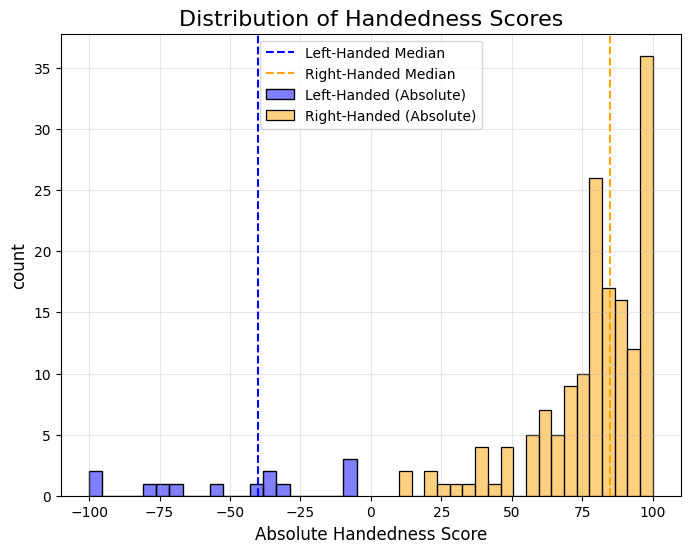

In [9]:
# Take absolute values of Handedness
left_handed_abs = left_handed['Handedness'].abs()
right_handed_abs = right_handed['Handedness'].abs()

plt.figure(figsize=(8, 6))
sns.histplot(left_handed['Handedness'], color='blue', label='Left-Handed (Absolute)', kde=False, bins=20, alpha=0.5)
sns.histplot(right_handed['Handedness'], color='orange', label='Right-Handed (Absolute)', kde=False, bins=20, alpha=0.5)


# mark medians
plt.axvline(left_handed['Handedness'].median(), color='blue', linestyle='--', label='Left-Handed Median')
plt.axvline(right_handed['Handedness'].median(), color='orange', linestyle='--', label='Right-Handed Median')

# Labels and title
plt.xlabel('Absolute Handedness Score', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.title('Distribution of Handedness Scores', fontsize=16)
plt.legend()

plt.grid(alpha=0.3)
plt.show()

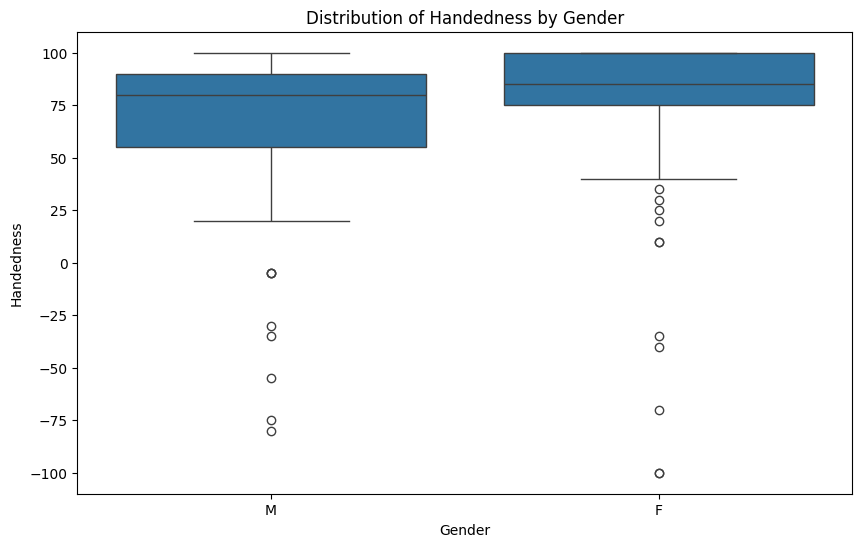

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=hand_data, x='Gender', y='Handedness')
plt.title("Distribution of Handedness by Gender")
plt.xlabel("Gender")
plt.ylabel("Handedness")
plt.show()

In [11]:
mmp_correlation_matrix_list = []
for i in range(mmp_data.shape[0]):
    person = mmp_data["Brain_Data"][i]
    #get matrix
    person_matrix = np.corrcoef(person.T)
    #append to list
    mmp_correlation_matrix_list.append(person_matrix)
#append to column
mmp_data["correlation_matrix"] = mmp_correlation_matrix_list

In [12]:
mmp_data['correlation_matrix']

0      [[1.0, 0.46619928616491757, 0.5387587799680043...
1      [[1.0, 0.4145113094959292, 0.342818966658749, ...
2      [[0.9999999999999998, 0.2989986241314227, 0.52...
3      [[0.9999999999999998, 0.5081583697070787, 0.59...
4      [[1.0, 0.5963831451011642, 0.6588621195832001,...
                             ...                        
167    [[1.0, 0.5868952668034533, 0.6650024441927097,...
168    [[1.0, 0.2527353927273103, 0.6220543671787876,...
169    [[1.0, 0.4077766140820082, 0.5679625164532214,...
170    [[0.9999999999999998, 0.4373132861456234, 0.65...
171    [[1.0, 0.1745251119720137, 0.5239475526043362,...
Name: correlation_matrix, Length: 172, dtype: object

In [47]:
mmp_regions = list(hcp.mmp.labels.values())[1:]
len(mmp_regions)

379

In [48]:
mmp_regions[:5]

[np.str_('L_V1'),
 np.str_('L_MST'),
 np.str_('L_V6'),
 np.str_('L_V2'),
 np.str_('L_V3')]

In [15]:
hcp.view_parcellation(hcp.mesh.inflated, hcp.mmp)

In [16]:
# hcp.parcellation_labels(hcp.mmp)

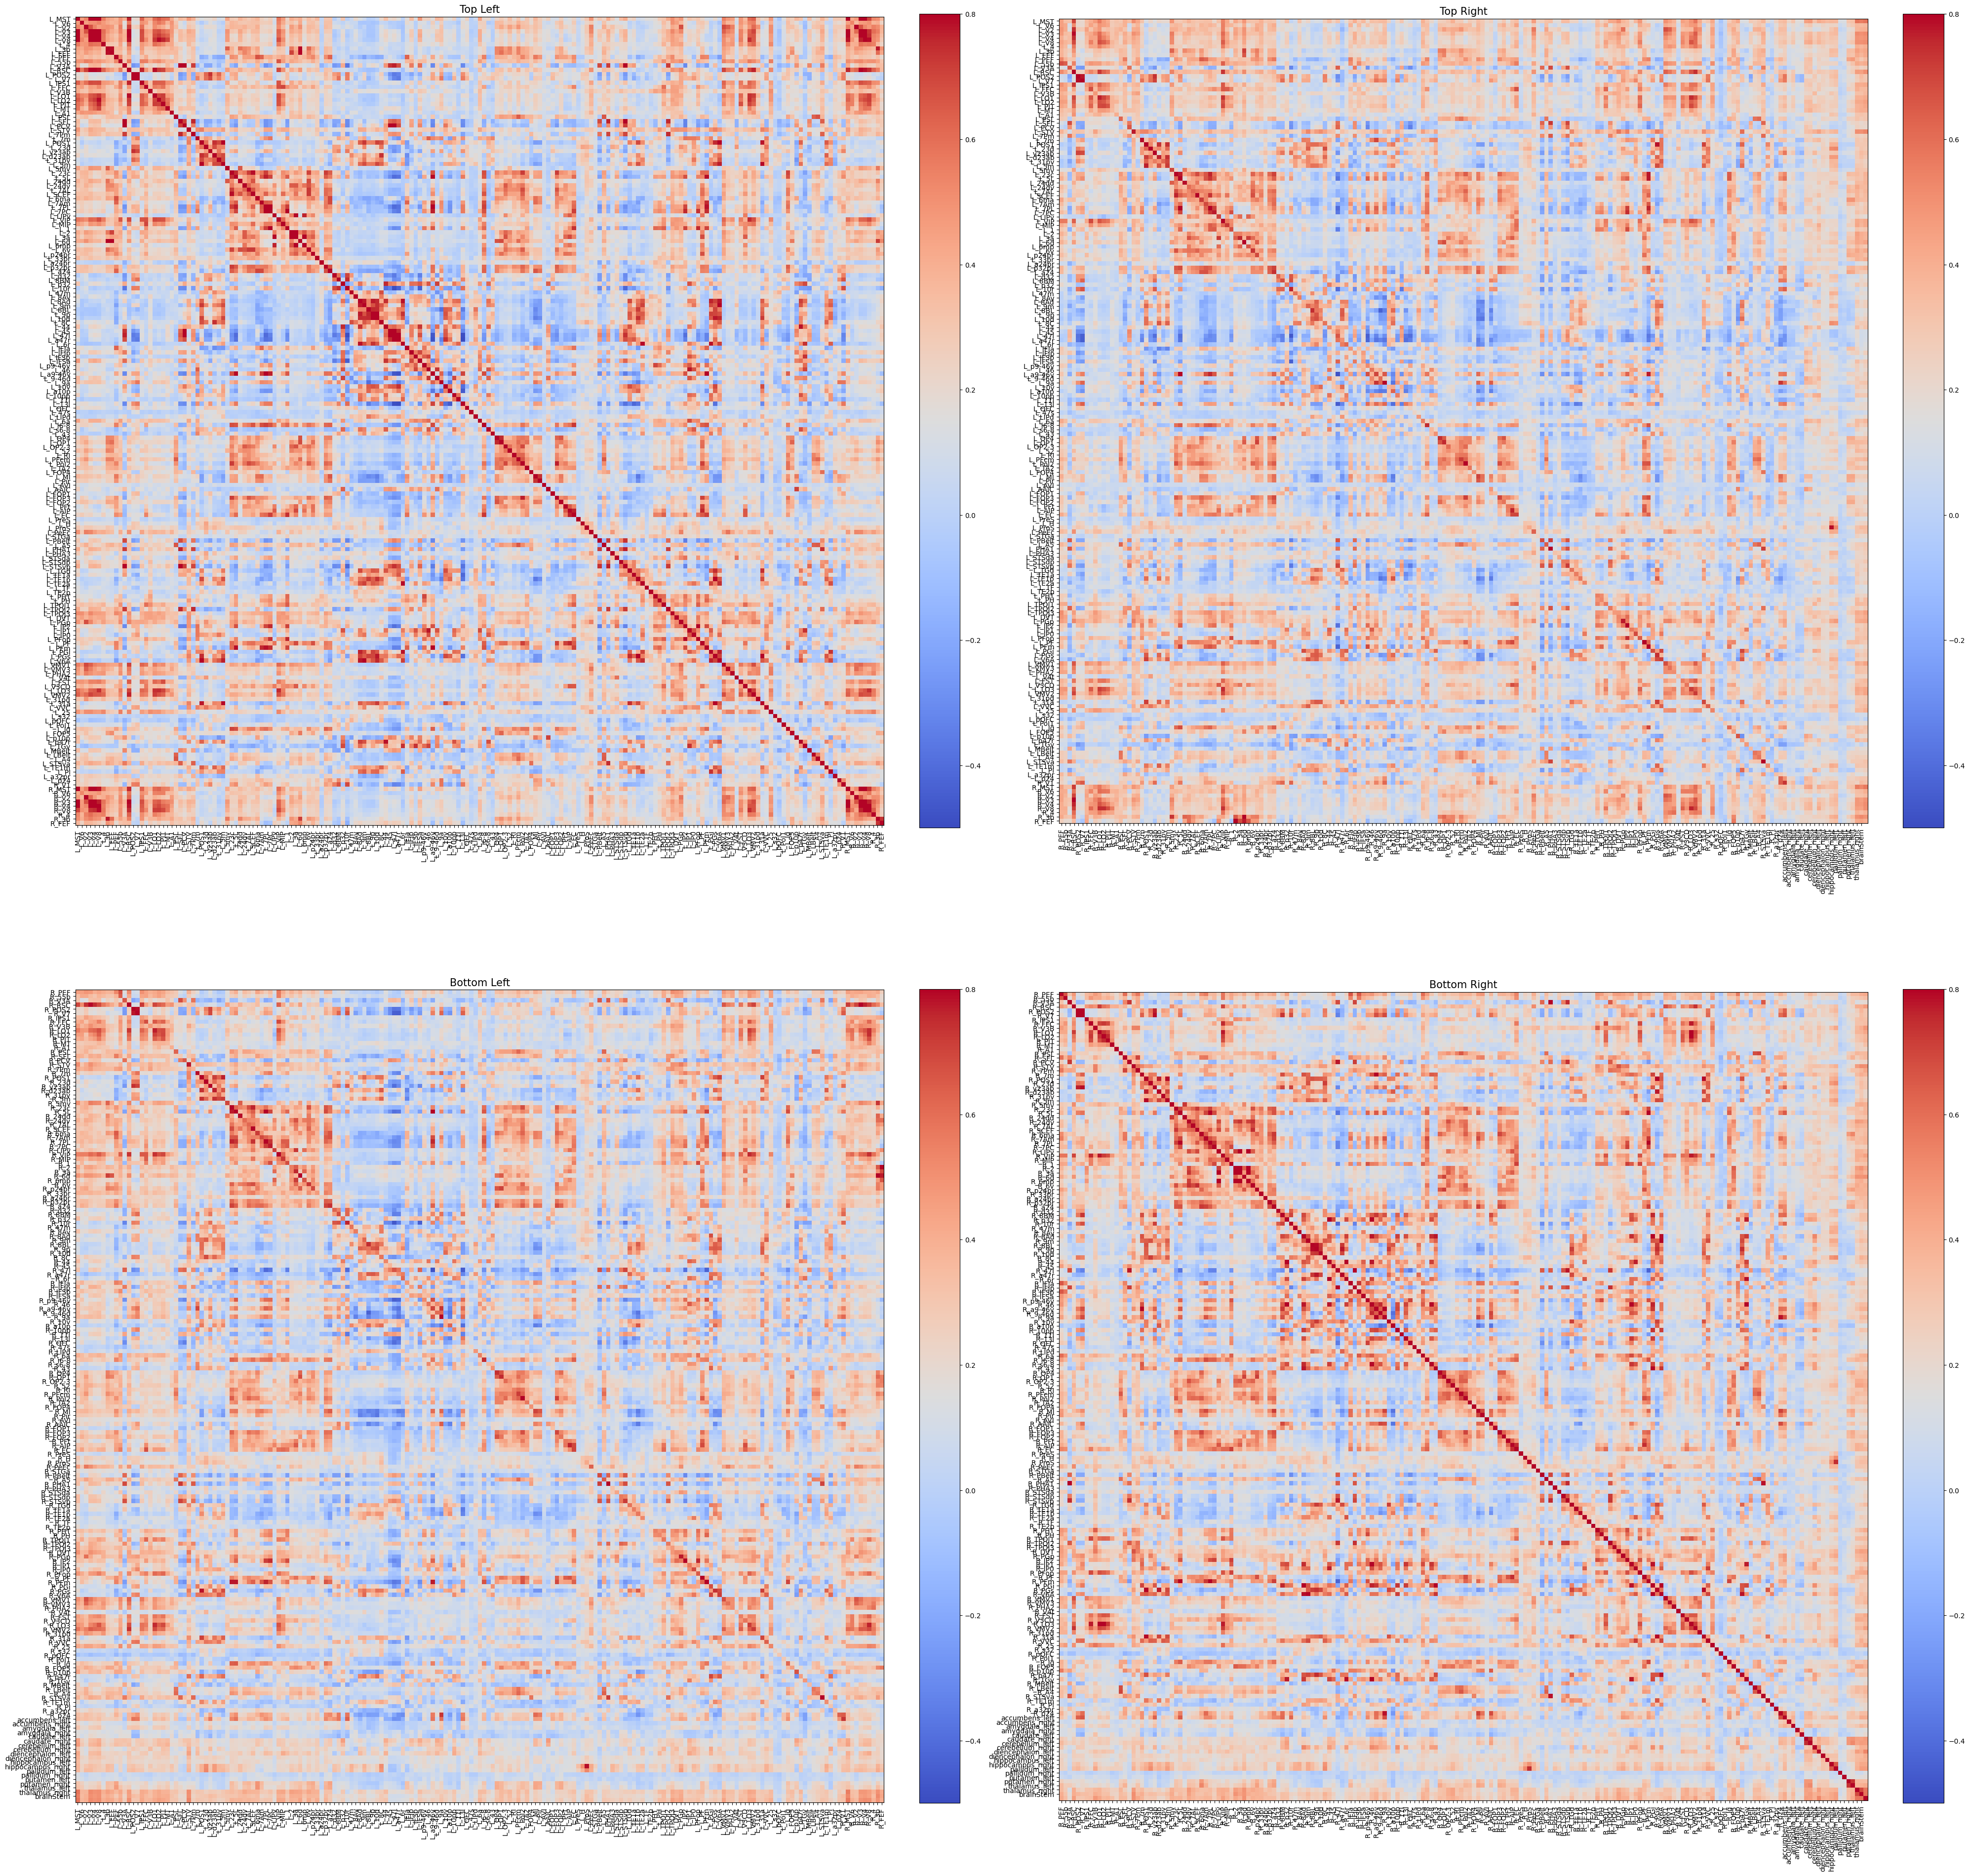

In [49]:
# Get the **first** correlation matrix to see for example
matrix = mmp_correlation_matrix_list[0]
labels = mmp_regions[1:] # mmp_regions[0] is just np.str_(''), leave it

# Define size of each quadrant
n = len(labels)  
half_n = n // 2  # Halfway point to split

fig, axes = plt.subplots(2, 2, figsize=(40, 40))

def plot_quadrant(ax, data, x_labels, y_labels, title):
    im = ax.imshow(data, cmap="coolwarm", vmin=-0.5, vmax=0.8)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels, fontsize=10, rotation=90)
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_title(title, fontsize=15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

# Top-left quadrant
plot_quadrant(axes[0, 0], matrix[:half_n, :half_n], labels[:half_n], labels[:half_n], "Top Left")

# Top-right quadrant
plot_quadrant(axes[0, 1], matrix[:half_n, half_n:], labels[half_n:], labels[:half_n], "Top Right")

# Bottom-left quadrant
plot_quadrant(axes[1, 0], matrix[half_n:, :half_n], labels[:half_n], labels[half_n:], "Bottom Left")

# Bottom-right quadrant
plot_quadrant(axes[1, 1], matrix[half_n:, half_n:], labels[half_n:], labels[half_n:], "Bottom Right")

plt.tight_layout()
plt.show()

In [55]:
# Dictionary to store sum of correlation values and count occurrences across subjects
pairwise_corr = {}

# Iterate over all correlation matrices (subjects)
for matrix in mmp_correlation_matrix_list:
    # Get the upper triangle of the matrix, excluding the diagonal
    triu_indices = np.triu_indices_from(matrix, k=1)
    values = matrix[triu_indices]

    # Get the region name pairs
    region_pairs = [(mmp_regions[i], mmp_regions[j]) for i, j in zip(*triu_indices)]

    # Create a DataFrame for sorting
    df = pd.DataFrame({
        "Region 1": [pair[0] for pair in region_pairs],
        "Region 2": [pair[1] for pair in region_pairs],
        "Correlation": values
    })

    # Sort by absolute correlation value (consider both positive and negative)
    df_sorted = df.sort_values(by="Correlation", ascending=False)
    
    # Select top 15 most positive and top 15 most negative correlations
    top_positive = df_sorted.head(15)
    top_negative = df_sorted.tail(15)  # Tail gets the most negative correlations

    # Combine both selections
    top_30 = pd.concat([top_positive, top_negative])

    # Aggregate correlation values for each region pair
    for _, row in top_30.iterrows():
        pair = (row["Region 1"], row["Region 2"])
        if pair not in pairwise_corr:
            pairwise_corr[pair] = {"sum": 0, "count": 0}
        pairwise_corr[pair]["sum"] += row["Correlation"]
        pairwise_corr[pair]["count"] += 1

# Compute average correlation values for each region pair
avg_corr_list = [
    {"Region 1": pair[0], "Region 2": pair[1], "Average Correlation": pairwise_corr[pair]["sum"] / pairwise_corr[pair]["count"]}
    for pair in pairwise_corr
]

# Convert to DataFrame and sort by absolute average correlation
df_avg_corr = pd.DataFrame(avg_corr_list).sort_values(by="Average Correlation", ascending=False)

# Select the final top 30 region pairs with highest absolute average correlation
final_top_30 = df_avg_corr.head(30)

# Display the results
print(final_top_30)

     Region 1 Region 2  Average Correlation
0        L_V1     R_V1             0.954988
1098     L_A4     R_A4             0.954090
1        L_V2     R_V2             0.942734
898     L_FFC    R_FFC             0.936894
865      L_V3     R_V1             0.927494
866      R_V1     R_V3             0.926878
540       L_1      R_2             0.924642
234      L_3b      R_1             0.922932
2        L_V2     L_V3             0.921081
415       L_4     R_3a             0.919865
578     L_SFL    R_SFL             0.919701
329     L_FEF    R_FEF             0.918987
113      L_3a      R_4             0.917899
199      R_9m     R_9p             0.916732
70        L_4     L_3a             0.916438
197      L_3b      L_1             0.916279
1016      L_4     L_3b             0.916278
11      L_V3A    R_V3A             0.915702
30       L_V3     R_V3             0.915024
69       L_3a     R_3a             0.913762
1067      L_1     R_3b             0.913597
36       L_V4     R_V4          

strong bilateral symmetry in primary sensory, motor, and visual areas
* the most correlated regions are not highly lateralized. 
* Since handedness is based on asymmetries in motor and prefrontal regions, these strong bilateral connections may not be the best predictors. 
* Try ca data and see if it has asymmetrical motor (M1, PMd, SMA) and association areas to improve classification accuracy.

In [56]:
handedness_regions = [
    # 1. Primary Motor & Somatosensory Cortex
    "L_4", "R_4",  # Primary Motor Cortex (M1)
    "L_1", "L_2", "L_3a", "R_1", "R_2", "R_3a",  # Somatosensory Cortex (S1)
    "L_3b", "R_3b",  # Secondary Somatosensory Cortex

    # 2. Premotor & Supplementary Motor Areas (SMA, PMd, PMv)
    "L_6mp", "R_6mp",  # Supplementary Motor Area (SMA)
    "L_6ma", "R_6ma",  # Medial Premotor Cortex
    "L_6d", "R_6d",  # Dorsal Premotor Cortex (PMd) - Reach, grasp control
    "L_6r", "R_6r",  # Rostral Premotor Cortex - Higher-order motor control
    "L_6a", "R_6a",  # Anterior Premotor Cortex
    "L_FEF", "R_FEF",  # Frontal Eye Fields (FEF) - Eye-hand coordination
    "L_6v", "R_6v", # Ventral Premotor Cortex (PMv), crucial for movement execution"

    # 3. Parietal Cortex & Sensorimotor Integration
    "L_IPS1", "R_IPS1",  # Intraparietal Sulcus (IPS) - Sensorimotor integration
    "L_LIPv", "R_LIPv",
    "L_LIPd", "R_LIPd",
    "L_7AL", "R_7AL",  # Superior Parietal Lobule (SPL) - Hand coordination
    "L_7m", "R_7m",
    "L_7PC", "R_7PC",

    # 4. Corpus Callosum & Interhemispheric Connections
    "L_31pv", "R_31pv",
    "L_31pd", "R_31pd",
    "L_24dd", "R_24dd",  # Dorsal Anterior Cingulate Cortex - Motor learning
    "L_24dv", "R_24dv",  # Ventral Anterior Cingulate Cortex

    # 6. Prefrontal Cortex (Executive & Motor Control)
    "L_9-46d", "R_9-46d",  # Dorsolateral Prefrontal Cortex (DLPFC) - Movement decision-making
    "L_46", "R_46",
    "L_44", "R_44",  # Broca's area - Language-motor integration
    "L_45", "R_45",

    # 7. Additional Relevant Motor Control Regions
    "L_SCEF", "R_SCEF",  # Supplementary & Cingulate Eye Fields
    "L_MIP", "R_MIP",  # Medial Intraparietal - Reach planning
    "L_VIP", "R_VIP",  # Ventral Intraparietal - Visuomotor integration
    
    # 8. Subcortical Motor-related Areas
    "putamen_left", "putamen_right",
    "caudate_left", "caudate_right",
    "thalamus_left", "thalamus_right",
    "cerebellum_left", "cerebellum_right",

    # 9. Brainstem - Motor relay
    "brainStem"
]


In [57]:
def feature_row_get(target):
    target_index = mmp_regions.index(target)
    target_row = mmp_data['correlation_matrix'].apply(lambda x: x[target_index])
    
    return target_row


In [58]:
# Function to extract features automatically
def extract_features(region_list, data):
    """
    Extracts the correlation matrix rows for each brain region in region_list.
    
    Parameters:
    - region_list: List of brain region names (e.g., ["L_MT", "L_4", "R_4"])
    - data: DataFrame containing "correlation_matrix"
    
    Returns:
    - DataFrame with extracted features
    """
    # Copy the relevant columns first
    feature_data = data[["Handedness", "Handedness_Cat", "correlation_matrix"]].copy()
    # print(feature_data.shape)

    # Compute the mean of the entire correlation matrix as a baseline feature
    feature_data["matrix_mean"] = data["correlation_matrix"].apply(lambda x: np.mean(x))

    # Apply feature_row_get() dynamically and store in a dictionary
    for region in region_list:
        feature_data[region] = feature_row_get(region)

    return feature_data


In [62]:
# Extract features for handedness prediction
feature_data = extract_features(handedness_regions, mmp_data)
feature_data

(172, 3)


,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_4,R_4,L_1,L_2,L_3a,R_1,...,R_VIP,putamen_left,putamen_right,caudate_left,caudate_right,thalamus_left,thalamus_right,cerebellum_left,cerebellum_right,brainStem
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[0.44603460807054096, 0.4180526599268045, 0.49...","[0.5058448287380618, 0.4015377697499112, 0.512...","[0.40548299302723256, 0.3255226507827946, 0.46...","[0.3554718317313472, 0.25483166802262797, 0.36...","[0.39900973227227443, 0.41345739128627873, 0.5...","[0.4285198311027231, 0.2874295191200353, 0.430...",...,"[0.4205647964065872, 0.3996089074985924, 0.323...","[0.3100933161756262, 0.24881346059399678, 0.17...","[0.3265738264531844, 0.2825369441278569, 0.198...","[0.4531293279504429, 0.2600933635242887, 0.193...","[0.4690835728576636, 0.2937425413721241, 0.214...","[0.5864892059883535, 0.3648707037374211, 0.371...","[0.5582765289662259, 0.35101745169885495, 0.38...","[0.3219879883512635, 0.17588412845479667, 0.11...","[0.4157853760774209, 0.18428982548096604, 0.12...","[0.5856313541418544, 0.363891982671451, 0.3986..."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[-0.03625874806779633, 0.3554951523299754, 0.5...","[-0.10786685793218385, 0.30606096530910526, 0....","[0.1866388091202092, 0.5719445130192548, 0.707...","[0.2012457043420382, 0.535342102420762, 0.6948...","[0.23877921379849432, 0.463670940844406, 0.631...","[0.1580324252276484, 0.5356620622060693, 0.686...",...,"[0.1599645226285731, 0.5225234971414285, 0.565...","[0.2989966594350158, 0.02963297790273026, -0.1...","[0.28908567047301875, -0.08507595951425063, -0...","[0.3322084077834872, -0.07981750386082631, -0....","[0.3014892519165118, -0.11160216043970941, -0....","[0.5825102955540145, 0.007198172227728307, -0....","[0.5496595299756764, -0.020745895635067197, -0...","[0.4318418228626399, 0.10786656654299008, -0.0...","[0.30321061554931156, -0.061161524824678085, -...","[0.5698083573040247, 0.34655284202675646, 0.29..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.2557007884462401, 0.4163673796361299, 0.587...","[0.3319607392943346, 0.4335608090685443, 0.660...","[0.30591984028492586, 0.3901975349387497, 0.58...","[0.325970189999188, 0.40499778505999673, 0.534...","[0.31330878401442297, 0.3703670853318901, 0.59...","[0.26419372754132087, 0.39141084680597066, 0.5...",...,"[0.41718919884300165, 0.4468556407881708, 0.58...","[0.3608501034288935, 0.08720571776315682, 0.11...","[0.3666126674932228, 0.04576551554754129, 0.10...","[0.3780522503651181, 0.11468560440687055, 0.15...","[0.36721388756832324, 0.053474729456464885, 0....","[0.5161074827653371, 0.17155229937390812, 0.23...","[0.5746687762566225, 0.13914864892984888, 0.25...","[0.5436292719235283, 0.33733431936603103, 0.42...","[0.5351185488250705, 0.354959720876679, 0.4086...","[0.5656910983821719, 0.3687751577105434, 0.502..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.4339877528645952, 0.5040271371932618, 0.628...","[0.37742673354089434, 0.4739060736846943, 0.60...","[0.3937560464391664, 0.5432009909529222, 0.607...","[0.40808604943560123, 0.5336622651926306, 0.59...","[0.4405457977953715, 0.4653121108483167, 0.614...","[0.3717411816742993, 0.5696178109082224, 0.613...",...,"[0.4546844875980681, 0.6817560118565841, 0.598...","[0.2148320182060796, 0.008706104476269587, 0.0...","[0.22165574154445203, 0.032556552822297496, 0....","[0.37398040300674507, 0.085619029663636, 0.003...","[0.33336466695949396, 0.03706321085712994, -0....","[0.521820363701444, 0.39598278258570213, 0.369...","[0.4775837813669714, 0.361452635371305, 0.3442...","[0.6201374288752123, 0.50124541190932, 0.38606...","[0.6101966415107055, 0.42786985669847777, 0.34...","[0.506131300140526, 0.48203909591560734, 0.494..."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[0.45387901174031836, 0.5127461328419858, 0.57...","[0.4722164765751269, 0.5332245212475473, 0.

In [63]:
def flatten_features(row, region_list):
    """
    Flattens selected brain region features into a single numpy array.
    
    Parameters:
    - row: A single row from the DataFrame
    - region_list: List of selected brain regions
    
    Returns:
    - 1D numpy array containing all extracted feature values
    """
    # Flatten the correlation matrix (if applicable)
    corr_mat = np.array(row["correlation_matrix"]).flatten()

    # Extract all relevant region values dynamically
    region_values = [np.array(row[region]) for region in region_list if region in row]

    # Concatenate into one feature array
    return np.concatenate(region_values)


In [64]:
feature_data_all = feature_data.copy()

In [65]:
filtered_df = feature_data[(feature_data['Handedness'] > 25) | (feature_data['Handedness'] < -25)]
feature_data = filtered_df
feature_data.shape

(164, 71)

could do random sampling of the right-handed group, but data size is too small

In [89]:
# Separate into left and right handed
left_handed = filtered_df[filtered_df['Handedness'] < 0]
right_handed = filtered_df[filtered_df['Handedness'] > 0]
print(left_handed.shape, right_handed.shape)

# Determine the number of samples to select from the right-handed data
num_samples = min(len(left_handed), len(right_handed))

# Randomly sample from the right-handed data
right_handed_sample = right_handed.sample(n=num_samples, random_state=42)

# Combine the left and right handed data
df_sampled = pd.concat([left_handed, right_handed_sample])
df_sampled.shape

# feature_data = df_sampled
# feature_data.shape

(10, 71) (154, 71)


(20, 71)

In [66]:
def SVM_w_sampling (sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    for i in range(5):
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)  # Convert to a 2D NumPy array
        y = feature_data["Handedness_Cat"]

        # Train-Test Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.4, stratify=None  # More variation by setting stratify=None
        )
        
        print(f"Run {i+1}: Before Oversampling - {Counter(y_train)}")

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print(f"After Oversampling - {Counter(y_train_resampled)}")

        # Train SVM Model
        model_class = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", probability=True, C=1.0, class_weight="balanced"))
        ])
        model_class.fit(X_train_resampled, y_train_resampled)
        y_pred = model_class.predict(X_test)

        # Balanced Accuracy & Confusion Matrix
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred) 
        conf_matrix = confusion_matrix(y_test, y_pred)

        print(f"Accuracy: {accuracy:.4f}, Balanced Accuracy: {balanced_acc:.4f}")
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval Calculation
        n_test = len(y_test)
        z_value = 1.96  # for ~95% CI
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)

        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        # Store results
        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final Results
    print(f"Final Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

In [67]:
SVM_w_sampling('SMOTE')

Run 1: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 2: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 3: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 4: Before Oversampling - Counter({1: 91, 0: 7})
After Oversampling - Counter({1: 91, 0: 91})
Accuracy: 0.9545, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  3]
 [ 0 63]]
95% CI for Accuracy: [0.9043, 1.0048]
Run 5: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9242, Balanced Accuracy

In [68]:
SVM_w_sampling('ADASYN')

Run 1: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({0: 95, 1: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 2: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({0: 95, 1: 93})
Accuracy: 0.9242, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 61]]
95% CI for Accuracy: [0.8604, 0.9881]
Run 3: Before Oversampling - Counter({1: 89, 0: 9})
After Oversampling - Counter({0: 91, 1: 89})
Accuracy: 0.9848, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  1]
 [ 0 65]]
95% CI for Accuracy: [0.9554, 1.0143]
Run 4: Before Oversampling - Counter({1: 91, 0: 7})
After Oversampling - Counter({0: 93, 1: 91})
Accuracy: 0.9545, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  3]
 [ 0 63]]
95% CI for Accuracy: [0.9043, 1.0048]
Run 5: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({0: 95, 1: 93})
Accuracy: 0.9242, Balanced Accuracy

In [69]:
SVM_w_sampling('RandomUnderSampler')

Run 1: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({0: 6, 1: 6})
Accuracy: 0.6667, Balanced Accuracy: 0.5887
Confusion Matrix:
 [[ 2  2]
 [20 42]]
95% CI for Accuracy: [0.5529, 0.7804]
Run 2: Before Oversampling - Counter({1: 91, 0: 7})
After Oversampling - Counter({0: 7, 1: 7})
Accuracy: 0.5758, Balanced Accuracy: 0.6190
Confusion Matrix:
 [[ 2  1]
 [27 36]]
95% CI for Accuracy: [0.4565, 0.6950]
Run 3: Before Oversampling - Counter({1: 91, 0: 7})
After Oversampling - Counter({0: 7, 1: 7})
Accuracy: 0.7424, Balanced Accuracy: 0.3889
Confusion Matrix:
 [[ 0  3]
 [14 49]]
95% CI for Accuracy: [0.6369, 0.8479]
Run 4: Before Oversampling - Counter({1: 93, 0: 5})
After Oversampling - Counter({0: 5, 1: 5})
Accuracy: 0.4091, Balanced Accuracy: 0.4049
Confusion Matrix:
 [[ 2  3]
 [36 25]]
95% CI for Accuracy: [0.2905, 0.5277]
Run 5: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({0: 4, 1: 4})
Accuracy: 0.7273, Balanced Accuracy: 0.5500
C

In [70]:
SVM_w_sampling('RandomOverSampler')

Run 1: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({1: 92, 0: 92})
Accuracy: 0.9394, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 62]]
95% CI for Accuracy: [0.8818, 0.9970]
Run 2: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({1: 92, 0: 92})
Accuracy: 0.9394, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 62]]
95% CI for Accuracy: [0.8818, 0.9970]
Run 3: Before Oversampling - Counter({1: 94, 0: 4})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9091, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 60]]
95% CI for Accuracy: [0.8397, 0.9784]
Run 4: Before Oversampling - Counter({1: 92, 0: 6})
After Oversampling - Counter({1: 92, 0: 92})
Accuracy: 0.9394, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 62]]
95% CI for Accuracy: [0.8818, 0.9970]
Run 5: Before Oversampling - Counter({1: 95, 0: 3})
After Oversampling - Counter({1: 95, 0: 95})
Accuracy: 0.8939, Balanced Accuracy

Only the training set is being resampled (either through SMOTE or undersampling), while the test set remains skewed. This means that even if the model learns to recognize left-handers better during training, it is still evaluated on a highly imbalanced test set, which can lead to misleading results.

In [71]:
def SVM_w_sampling_tuning(sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    # Define the SVM pipeline
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(probability=True))
    ])

    # Define hyperparameter grid for tuning
    param_grid = {
        "svc__C": [0.1, 1, 10],  
        "svc__gamma": ["scale", "auto"],  
        "svc__kernel": ["rbf", "linear"],
        "svc__class_weight": ["balanced"]
    }

    for i in range(3):
        print(f"\n===== Run {i+1} =====")
        
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)
        y = feature_data["Handedness_Cat"]

        # Train-test split (random_state=None for different splits each time)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.5, stratify=y, random_state=None
        )
        
        print("Before Sampling:", Counter(y_train)) 

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print("After Sampling:", Counter(y_train_resampled))  

        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="balanced_accuracy")
        grid_search.fit(X_train_resampled, y_train_resampled)

        # Best model after tuning
        best_model = grid_search.best_estimator_

        # Make predictions
        y_pred = best_model.predict(X_test)

        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        print("Best Hyperparameters:", grid_search.best_params_)
        print("Accuracy of SVM Model:", accuracy)
        print("Balanced Accuracy:", balanced_acc)
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval for Accuracy
        n_test = len(y_test)
        z_value = 1.96  
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)
        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final results
    print(f"\nFinal Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

In [72]:
SVM_w_sampling_tuning('SMOTE')


===== Run 1 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 2 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 3 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  

In [73]:
SVM_w_sampling_tuning('ADASYN')


===== Run 1 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({0: 77, 1: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.9512195121951219
Balanced Accuracy: 0.6
Confusion Matrix:
 [[ 1  4]
 [ 0 77]]
95% CI for Accuracy: [0.9046, 0.9978]

===== Run 2 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({0: 79, 1: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 3 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]

In [124]:
SVM_w_sampling_tuning('RandomOverSampler')


===== Run 1 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 2 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [ 0 77]]
95% CI for Accuracy: [0.8872, 0.9908]

===== Run 3 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({1: 77, 0: 77})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9390243902439024
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  5]
 [

In [126]:
SVM_w_sampling('RandomUnderSampler')


===== Run 1 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 10, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.6951219512195121
Balanced Accuracy: 0.37012987012987014
Confusion Matrix:
 [[ 0  5]
 [20 57]]
95% CI for Accuracy: [0.5955, 0.7948]

===== Run 2 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 10, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.6341463414634146
Balanced Accuracy: 0.4311688311688312
Confusion Matrix:
 [[ 1  4]
 [26 51]]
95% CI for Accuracy: [0.5299, 0.7384]

===== Run 3 =====
Before SMOTE: Counter({1: 77, 0: 5})
After SMOTE: Counter({0: 5, 1: 5})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.36585365853658536
Balanced Accuracy: 0.4753

In [74]:
def SVM_w_sampling_tuning(sampling_method):

    test_result = []
    trial_ci = []
    trial_acc = []

    # Define the SVM pipeline
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(probability=True))
    ])

    # Define hyperparameter grid for tuning
    param_grid = {
        "svc__C": [0.1, 1, 10],  
        "svc__gamma": ["scale", "auto"],  
        "svc__kernel": ["rbf", "linear"],
        "svc__class_weight": ["balanced"]
    }

    for i in range(3):
        print(f"\n===== Run {i+1} =====")
        
        # Feature extraction
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X = np.vstack(X_list.values)
        y = feature_data["Handedness_Cat"]

        # Train-test split (random_state=None for different splits each time)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.5, stratify=y, random_state=None
        )
        
        print("Before Sampling:", Counter(y_train)) 

        # Determine the smallest class count
        min_class_count = min(Counter(y_train).values())

        # Set k_neighbors dynamically (must be < min_class_count)
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        # Apply oversampling only on the training set
        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == 'RandomUnderSampler':
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == 'RandomOverSampler':
            sampler = RandomOverSampler(random_state=None)

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

        print("After Sampling:", Counter(y_train_resampled))  

        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="balanced_accuracy")
        grid_search.fit(X_train_resampled, y_train_resampled)

        # Best model after tuning
        best_model = grid_search.best_estimator_

        # Make predictions
        y_pred = best_model.predict(X_test)

        # Compute performance metrics
        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        print("Best Hyperparameters:", grid_search.best_params_)
        print("Accuracy of SVM Model:", accuracy)
        print("Balanced Accuracy:", balanced_acc)
        print("Confusion Matrix:\n", conf_matrix)

        # 95% Confidence Interval for Accuracy
        n_test = len(y_test)
        z_value = 1.96  
        std_error = math.sqrt(accuracy * (1 - accuracy) / n_test)
        ci_lower = accuracy - z_value * std_error
        ci_upper = accuracy + z_value * std_error

        print(f"95% CI for Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]")

        trial_ci.append([ci_lower, ci_upper])
        trial_acc.append(balanced_acc)
        test_result.append(accuracy)

    # Final results
    print(f"\nFinal Average Accuracy: {np.mean(test_result):.4f}")
    print(f"Final Average Balanced Accuracy: {np.mean(trial_acc):.4f}")

Initially, SVM was overfitting (SMOTE, ADASYN, or RandomOverSampling), all right-handed predictions and 0 left-handed predictions, leading to high accuracy (~94%) but a balanced accuracy of ~0.5.

I tried undersampling the majority class, which reduced overfitting (accuracy ~65%, balanced accuracy ~0.55). The challenge now is that the dataset has very few left-handers, and SMOTE can’t create reliable synthetic samples from such limited data. I'm considering manually balancing the test set or re-evaluating whether rs-fMRI features contain enough lateralization signals to predict handedness reliably. 



### CNN

In [90]:
feature_data_all = feature_data_all[(feature_data_all['Handedness'] > 25) | (feature_data_all['Handedness'] < -25)]
feature_data_all.head()

,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_4,R_4,L_1,L_2,L_3a,R_1,...,R_VIP,putamen_left,putamen_right,caudate_left,caudate_right,thalamus_left,thalamus_right,cerebellum_left,cerebellum_right,brainStem
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[0.44603460807054096, 0.4180526599268045, 0.49...","[0.5058448287380618, 0.4015377697499112, 0.512...","[0.40548299302723256, 0.3255226507827946, 0.46...","[0.3554718317313472, 0.25483166802262797, 0.36...","[0.39900973227227443, 0.41345739128627873, 0.5...","[0.4285198311027231, 0.2874295191200353, 0.430...",...,"[0.4205647964065872, 0.3996089074985924, 0.323...","[0.3100933161756262, 0.24881346059399678, 0.17...","[0.3265738264531844, 0.2825369441278569, 0.198...","[0.4531293279504429, 0.2600933635242887, 0.193...","[0.4690835728576636, 0.2937425413721241, 0.214...","[0.5864892059883535, 0.3648707037374211, 0.371...","[0.5582765289662259, 0.35101745169885495, 0.38...","[0.3219879883512635, 0.17588412845479667, 0.11...","[0.4157853760774209, 0.18428982548096604, 0.12...","[0.5856313541418544, 0.363891982671451, 0.3986..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.2557007884462401, 0.4163673796361299, 0.587...","[0.3319607392943346, 0.4335608090685443, 0.660...","[0.30591984028492586, 0.3901975349387497, 0.58...","[0.325970189999188, 0.40499778505999673, 0.534...","[0.31330878401442297, 0.3703670853318901, 0.59...","[0.26419372754132087, 0.39141084680597066, 0.5...",...,"[0.41718919884300165, 0.4468556407881708, 0.58...","[0.3608501034288935, 0.08720571776315682, 0.11...","[0.3666126674932228, 0.04576551554754129, 0.10...","[0.3780522503651181, 0.11468560440687055, 0.15...","[0.36721388756832324, 0.053474729456464885, 0....","[0.5161074827653371, 0.17155229937390812, 0.23...","[0.5746687762566225, 0.13914864892984888, 0.25...","[0.5436292719235283, 0.33733431936603103, 0.42...","[0.5351185488250705, 0.354959720876679, 0.4086...","[0.5656910983821719, 0.3687751577105434, 0.502..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.4339877528645952, 0.5040271371932618, 0.628...","[0.37742673354089434, 0.4739060736846943, 0.60...","[0.3937560464391664, 0.5432009909529222, 0.607...","[0.40808604943560123, 0.5336622651926306, 0.59...","[0.4405457977953715, 0.4653121108483167, 0.614...","[0.3717411816742993, 0.5696178109082224, 0.613...",...,"[0.4546844875980681, 0.6817560118565841, 0.598...","[0.2148320182060796, 0.008706104476269587, 0.0...","[0.22165574154445203, 0.032556552822297496, 0....","[0.37398040300674507, 0.085619029663636, 0.003...","[0.33336466695949396, 0.03706321085712994, -0....","[0.521820363701444, 0.39598278258570213, 0.369...","[0.4775837813669714, 0.361452635371305, 0.3442...","[0.6201374288752123, 0.50124541190932, 0.38606...","[0.6101966415107055, 0.42786985669847777, 0.34...","[0.506131300140526, 0.48203909591560734, 0.494..."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[0.45387901174031836, 0.5127461328419858, 0.57...","[0.4722164765751269, 0.5332245212475473, 0.588...","[0.45131751729769015, 0.6203443289412882, 0.62...","[0.47605793011712233, 0.6169004247170177, 0.63...","[0.4501691592901647, 0.5057578623073685, 0.573...","[0.3908995126741607, 0.5730176059653078, 0.605...",...,"[0.3911050395306357, 0.5068618107675378, 0.518...","[0.409589966112803, 0.1870437644705693, 0.2142...","[0.43619694419036736, 0.2178596227883606, 0.22...","[0.4549512928272244, 0.22329135518430296, 0.16...","[0.4149320536046716, 0.1828382032034893, 0.112...","[0.5817626111058815, 0.22423481495504216, 0.16...","[0.5677207807084473, 0.1931839691101451, 0.141...","[0.5744702428353304, 0.3329368391530414, 0.257...","[0.5527461559379574, 0.3694632424745314, 0.284...","[0.6127400730147264, 0.36621553348388114, 0.36..."
5,80,1,"[[1.0, 0.18865462873613795, 0.472518781401885,...",0.158403,"[0.33844286019930564, 0.23563124206811345, 0.2...","[0.38799783219074346, 0.2637854508916938, 0

In [91]:
feature_data_all.shape

(164, 71)

In [92]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import pandas as pd

In [100]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import pandas as pd

def CNN_w_sampling(sampling_method, test_size=0.3, batch_size=16, epochs=20, num_runs=5):
    """
    Builds and trains a CNN for handedness prediction using:
    - Features from flatten_features()
    - Flattened correlation_matrix values

    Parameters:
    - sampling_method: Type of resampling ('SMOTE', 'ADASYN', 'RandomOverSampler', 'RandomUnderSampler').
    - test_size: Proportion of dataset allocated for testing.
    - batch_size: Training batch size.
    - epochs: Number of training epochs.
    - num_runs: Number of independent runs for variability in results.

    Returns:
    - DataFrame with summarized results across runs.
    """

    test_results = []

    for i in range(1, num_runs + 1):
        print(f"\n===== RUN {i} =====")

        # -------------------------------
        # 1. Feature Extraction (Unified X)
        # -------------------------------
        # Extract features using flatten_features()
        X_list = feature_data.apply(lambda row: flatten_features(row, handedness_regions), axis=1)
        X_features = np.vstack(X_list.values)  # shape: (n_samples, num_features)

        # Flatten correlation matrices and add as additional features
        X_corr_flattened = np.array(feature_data["correlation_matrix"].tolist()).reshape(X_features.shape[0], -1)  

        # Combine both into a single X
        X = np.hstack([X_features, X_corr_flattened])  # Final X shape: (n_samples, num_features + flattened_corr)

        # Target variable
        y = feature_data["Handedness_Cat"]

        # -------------------------------
        # 2. Train-Test Split
        # -------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=None
        )

        print(f"Run {i}: Before Sampling - {Counter(y_train)}")

        # -------------------------------
        # 3. Standardize Features
        # -------------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # -------------------------------
        # 4. Apply Oversampling to Training Set
        # -------------------------------
        min_class_count = min(Counter(y_train).values())  # Determine smallest class count
        k_neighbors = max(1, min(5, min_class_count - 1))  # Ensure k_neighbors is valid

        if sampling_method == "SMOTE":
            sampler = SMOTE(k_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "ADASYN":
            sampler = ADASYN(n_neighbors=k_neighbors, random_state=None)
        elif sampling_method == "RandomUnderSampler":
            sampler = RandomUnderSampler(random_state=None)
        elif sampling_method == "RandomOverSampler":
            sampler = RandomOverSampler(random_state=None)
        else:
            raise ValueError("Invalid sampling method. Choose from 'SMOTE', 'ADASYN', 'RandomOverSampler', or 'RandomUnderSampler'.")

        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)

        print(f"After Sampling - {Counter(y_train_resampled)}")

        # -------------------------------
        # 5. Build CNN Model
        # -------------------------------
        input_features = Input(shape=(X_train_resampled.shape[1],), name="feature_input")
        x = Dense(128, activation="relu")(input_features)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Dense(64, activation="relu")(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        output = Dense(1, activation="sigmoid")(x)

        model = Model(inputs=input_features, outputs=output)
        model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

        # -------------------------------
        # 6. Train Model
        # -------------------------------
        model.fit(
            X_train_resampled, y_train_resampled,
            validation_data=(X_test_scaled, y_test),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  # Hide training output
        )

        # -------------------------------
        # 7. Evaluate Model
        # -------------------------------
        y_pred_probs = model.predict(X_test_scaled)
        y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary labels

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        print('y_test:', Counter(y_test))
        print("\nClassification Report:\n", classification_report(y_test, y_pred))
        print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print(f"\nRun {i} Metrics:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")

        # Store results
        test_results.append({
            "Run": i,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Balanced Accuracy": balanced_acc
        })

    # Final Results
    df_results = pd.DataFrame(test_results)
    print("\n===== FINAL SUMMARY ACROSS RUNS =====")
    print(df_results)
    print("\nMean Performance:")
    print(df_results.mean())

    return model, df_results


In [101]:
CNN_w_sampling('RandomUnderSampler', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 7, 1: 7})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.07      0.67      0.13         3
           1       0.95      0.45      0.61        47

    accuracy                           0.46        50
   macro avg       0.51      0.56      0.37        50
weighted avg       0.90      0.46      0.58        50


Confusion Matrix:
 [[ 2  1]
 [26 21]]

Run 1 Metrics:
Accuracy: 0.4600
Precision: 0.9545
Recall: 0.4468
F1 Score: 0.6087
Balanced Accuracy: 0.5567

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 7, 1: 7})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.07      0.67      0.13         3
           1 

(<Functional name=functional_15, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.46   0.954545  0.446809  0.608696           0.556738
 1    2      0.48   0.956522  0.468085  0.628571           0.567376
 2    3      0.46   0.916667  0.468085  0.619718           0.400709
 3    4      0.48   0.920000  0.489362  0.638889           0.411348
 4    5      0.32   0.933333  0.297872  0.451613           0.482270)

In [99]:
CNN_w_sampling('SMOTE', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Oversampling - Counter({1: 107, 0: 7})
After Oversampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 1 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 2 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 2: Before Oversampling - Counter({1: 107, 0: 7})
After Oversampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.96      1.00      0.98        47

    accuracy                           0.96        50
   macro avg       0.98      0.67      0.74        50
weighted avg       0.96      0.96      0.95        50


Confusion Matrix:
 [[ 1  2]
 [ 0 47]]

Run 2 Metrics:
Accuracy: 0.9600
Precision: 0.9592
Recall: 1.0000
F1 Score: 0.9792
Balanced Accuracy: 0.6667

===== RUN 3 =====
Run 3: Before Oversampling - Counter({1: 107, 0: 7})
After Oversampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy    

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 4: Before Oversampling - Counter({1: 107, 0: 7})
After Oversampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.98      0.96        47

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50


Confusion Matrix:
 [[ 0  3]
 [ 1 46]]

Run 4 Metrics:
Accuracy: 0.9200
Precision: 0.9388
Recall: 0.9787
F1 Score: 0.9583
Balanced Accuracy: 0.4894

===== RUN 5 =====
Run 5: Before Oversampling - Counter({1: 107, 0: 7})
After Oversampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.96      0.95        47

    accuracy    

(<Functional name=functional_10, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.94   0.940000  1.000000  0.969072           0.500000
 1    2      0.96   0.959184  1.000000  0.979167           0.666667
 2    3      0.94   0.940000  1.000000  0.969072           0.500000
 3    4      0.92   0.938776  0.978723  0.958333           0.489362
 4    5      0.90   0.937500  0.957447  0.947368           0.478723)

In [102]:
CNN_w_sampling('ADASYN', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 110, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 1 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 2 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 109, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.96      0.98      0.97        47

    accuracy                           0.94        50
   macro avg       0.73      0.66      0.68        50
weighted avg       0.93      0.94      0.93        50


Confusion Matrix:
 [[ 1  2]
 [ 1 46]]

Run 2 Metrics:
Accuracy: 0.9400
Precision: 0.9583
Recall: 0.9787
F1 Score: 0.9684
Balanced Accuracy: 0.6560

===== RUN 3 =====
Run 3: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 109, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94  

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 5: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({0: 110, 1: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      0.98      0.96        47

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50


Confusion Matrix:
 [[ 0  3]
 [ 1 46]]

Run 5 Metrics:
Accuracy: 0.9200
Precision: 0.9388
Recall: 0.9787
F1 Score: 0.9583
Balanced Accuracy: 0.4894

===== FINAL SUMMARY ACROSS RUNS =====
   Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
0    1      0.94   0.940000  1.000000  0.969072           0.500000
1    2      0.94   0.958333  0.978723  0.968421           0.656028
2    3      0.92   0.938776  0.978723  0.958333           0.489362
3    4      0.94   0.940000  1.0

(<Functional name=functional_20, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1      0.94   0.940000  1.000000  0.969072           0.500000
 1    2      0.94   0.958333  0.978723  0.968421           0.656028
 2    3      0.92   0.938776  0.978723  0.958333           0.489362
 3    4      0.94   0.940000  1.000000  0.969072           0.500000
 4    5      0.92   0.938776  0.978723  0.958333           0.489362)

In [103]:
CNN_w_sampling('RandomOverSampler', test_size=0.3, batch_size=16, epochs=20, num_runs=5)


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 1 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 2 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 2: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 2 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 3 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 3: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 3 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 4 =====
Run 4: Before Sampling - Counter({1: 107, 0: 7})


...

After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 4 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== RUN 5 =====


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 5: Before Sampling - Counter({1: 107, 0: 7})
After Sampling - Counter({1: 107, 0: 107})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
y_test: Counter({1: 47, 0: 3})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        47

    accuracy                           0.94        50
   macro avg       0.47      0.50      0.48        50
weighted avg       0.88      0.94      0.91        50


Confusion Matrix:
 [[ 0  3]
 [ 0 47]]

Run 5 Metrics:
Accuracy: 0.9400
Precision: 0.9400
Recall: 1.0000
F1 Score: 0.9691
Balanced Accuracy: 0.5000

===== FINAL SUMMARY ACROSS RUNS =====
   Run  Accuracy  Precision  Recall  F1 Score  Balanced Accuracy
0    1      0.94       0.94     1.0  0.969072                0.5
1    2      0.94       0.94     1.0  0.969072                0.5
2    3      0.94       0.94     1.0  0.969072                0.5
3    4      0.94       0.94     1.0  0.9

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(<Functional name=functional_25, built=True>,
    Run  Accuracy  Precision  Recall  F1 Score  Balanced Accuracy
 0    1      0.94       0.94     1.0  0.969072                0.5
 1    2      0.94       0.94     1.0  0.969072                0.5
 2    3      0.94       0.94     1.0  0.969072                0.5
 3    4      0.94       0.94     1.0  0.969072                0.5
 4    5      0.94       0.94     1.0  0.969072                0.5)

If after all of this, balanced accuracy is ~0.5, it’s possible that rfMRI correlations aren’t sufficient to predict handedness.

Instead of the `handedness_regions`, use the significant regions that Daniel found in `zhuoxuan_feature_finding` notebook

In [104]:
significant_regions = ['L_SFL', 'L_1', 'L_44', 'L_OFC', 'L_TA2', 'L_PHA1', 'L_TE1a', 'L_DVT', 'L_pOFC', 'R_PEF', 'R_VIP', 'R_1', 'R_11l', 'R_OP4', 'R_OP2-3', 'R_PFcm', 'R_H', 'R_31pd']

In [106]:
# Extract features for handedness prediction using significant regions only
feature_data = extract_features(significant_regions, mmp_data)
feature_data

(172, 3)


,Handedness,Handedness_Cat,correlation_matrix,matrix_mean,L_SFL,L_1,L_44,L_OFC,L_TA2,L_PHA1,...,L_pOFC,R_PEF,R_VIP,R_1,R_11l,R_OP4,R_OP2-3,R_PFcm,R_H,R_31pd
0,85,1,"[[1.0, 0.46619928616491757, 0.5387587799680043...",0.175993,"[0.3231818293285933, 0.05654510021135424, 0.10...","[0.40548299302723256, 0.3255226507827946, 0.46...","[0.18769119250623695, -0.03247958017999629, 0....","[-0.00896086940499581, -0.0009267744574111396,...","[0.19717832154389545, 0.18318945343147044, 0.2...","[0.2730769869303734, 0.13747693271662473, 0.32...",...,"[0.14748978258422882, 0.08180267581047104, 0.1...","[0.3329013935755421, 0.41701490613493913, 0.41...","[0.4205647964065872, 0.3996089074985924, 0.323...","[0.4285198311027231, 0.2874295191200353, 0.430...","[0.1514348770978374, 0.16488687470795674, 0.11...","[0.26240956085829736, 0.30196211026039016, 0.4...","[0.39555475648252036, 0.30317881062080554, 0.4...","[0.17288038170138673, 0.3374536196379342, 0.36...","[0.23871016190416916, 0.15422921859463767, 0.2...","[0.25153981626071253, 0.010101548149905461, 0...."
1,10,1,"[[1.0, 0.4145113094959292, 0.342818966658749, ...",0.186351,"[0.06698753717245602, -0.001580193770690181, 0...","[0.1866388091202092, 0.5719445130192548, 0.707...","[0.13676359745648892, -0.02797425907077241, -0...","[0.11493805025934718, -0.0013849737419006226, ...","[0.043110057415732775, 0.3447825649399157, 0.4...","[0.17406376876018168, 0.17651927275145093, 0.3...",...,"[0.1472324962964217, -0.024880862479216823, -0...","[0.07238388864994358, 0.4032154858329246, 0.46...","[0.1599645226285731, 0.5225234971414285, 0.565...","[0.1580324252276484, 0.5356620622060693, 0.686...","[0.14278950745532318, -0.009159514255934956, -...","[0.17400213798792433, 0.4307686398020671, 0.54...","[0.40046465943884524, 0.35181316194880685, 0.4...","[0.14236476794781466, 0.4921388315840523, 0.56...","[0.2648126642646149, 0.18479058542143983, 0.19...","[0.14526858366687959, -0.09532112804837921, -0..."
2,100,1,"[[0.9999999999999998, 0.2989986241314227, 0.52...",0.258471,"[0.0918866283273426, 0.19386798179533493, 0.20...","[0.30591984028492586, 0.3901975349387497, 0.58...","[0.2536316598394608, 0.19404334824825625, 0.37...","[-0.02801172671975958, -0.04697965457753488, -...","[0.2198098596093181, 0.23114000824523867, 0.27...","[0.36646897028720277, 0.39874347884005007, 0.5...",...,"[-0.019619433739468443, -0.0046764236749861346...","[0.34036289008197357, 0.289746822627155, 0.437...","[0.41718919884300165, 0.4468556407881708, 0.58...","[0.26419372754132087, 0.39141084680597066, 0.5...","[0.34569407436177335, 0.1494121493081389, 0.25...","[0.41373521794675144, 0.33028894511079593, 0.6...","[0.44533340219237627, 0.27793781425111846, 0.5...","[0.4060008930264692, 0.33263416123880224, 0.50...","[0.2608292245850585, 0.3772893078121869, 0.400...","[0.3624888532832297, 0.2656802231290284, 0.272..."
3,65,1,"[[0.9999999999999998, 0.5081583697070787, 0.59...",0.211318,"[0.29087313908719487, 0.2224430676971492, 0.20...","[0.3937560464391664, 0.5432009909529222, 0.607...","[0.22126890579465794, 0.21479480215111704, 0.1...","[0.10089722157103038, 0.020052195241493882, -0...","[0.08259814464532861, 0.3866003735432504, 0.44...","[0.15509847854819422, 0.10540327848196956, 0.1...",...,"[-0.07915703705313956, -0.04486858125668527, -...","[0.27986084978719594, 0.5374640024219773, 0.48...","[0.4546844875980681, 0.6817560118565841, 0.598...","[0.3717411816742993, 0.5696178109082224, 0.613...","[0.22275080214774204, 0.08456732127690333, 0.1...","[0.3021224600625375, 0.4480134547876782, 0.612...","[0.4045878721336501, 0.45058199032370183, 0.56...","[0.31621284091898877, 0.5339321991098424, 0.56...","[0.15404737668443316, 0.22019327330562305, 0.1...","[0.1637346467651524, -0.04210453002674888, -0...."
4,35,1,"[[1.0, 0.5963831451011642, 0.6588621195832001,...",0.327927,"[0.24140340892238749, 0.1873466908727359, 0.17...","[0.45131751729769015, 0.6203443289412882, 0.62...","[0.270217899258357, 0.19558515200519314, 0.249...","[

In [107]:
SVM_w_sampling('SMOTE')

Run 1: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8986, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  7]
 [ 0 62]]
95% CI for Accuracy: [0.8273, 0.9698]
Run 2: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9420, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 65]]
95% CI for Accuracy: [0.8869, 0.9972]
Run 3: Before Oversampling - Counter({1: 91, 0: 12})
After Oversampling - Counter({1: 91, 0: 91})
Accuracy: 0.9855, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  1]
 [ 0 68]]
95% CI for Accuracy: [0.9573, 1.0137]
Run 4: Before Oversampling - Counter({1: 93, 0: 10})
After Oversampling - Counter({1: 93, 0: 93})
Accuracy: 0.9565, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  3]
 [ 0 66]]
95% CI for Accuracy: [0.9084, 1.0046]
Run 5: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9420, Balanced Accura

In [118]:
SVM_w_sampling_tuning('SMOTE')


===== Run 1 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0 80]]
95% CI for Accuracy: [0.8764, 0.9841]

===== Run 2 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0 80]]
95% CI for Accuracy: [0.8764, 0.9841]

===== Run 3 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0

In [108]:
SVM_w_sampling('ADASYN')

Run 1: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({0: 95, 1: 94})
Accuracy: 0.9275, Balanced Accuracy: 0.4923
Confusion Matrix:
 [[ 0  4]
 [ 1 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 2: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({1: 96, 0: 96})
Accuracy: 0.9130, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 63]]
95% CI for Accuracy: [0.8466, 0.9795]
Run 3: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 94})
Accuracy: 0.9275, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 4: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({1: 96, 0: 95})
Accuracy: 0.9130, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 63]]
95% CI for Accuracy: [0.8466, 0.9795]
Run 5: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 90})
Accuracy: 0.9420, Balanced Accuracy

In [114]:
SVM_w_sampling_tuning('ADASYN')


===== Run 1 =====
Before SMOTE: Counter({1: 80, 0: 6})
After SMOTE: Counter({1: 80, 0: 78})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  7]
 [ 0 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 2 =====
Before SMOTE: Counter({1: 80, 0: 6})
After SMOTE: Counter({1: 80, 0: 80})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  7]
 [ 0 79]]
95% CI for Accuracy: [0.8608, 0.9764]

===== Run 3 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({0: 80, 1: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0

In [109]:
SVM_w_sampling('RandomOverSampler')

Run 1: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({1: 96, 0: 96})
Accuracy: 0.9130, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  6]
 [ 0 63]]
95% CI for Accuracy: [0.8466, 0.9795]
Run 2: Before Oversampling - Counter({1: 97, 0: 6})
After Oversampling - Counter({1: 97, 0: 97})
Accuracy: 0.8841, Balanced Accuracy: 0.4919
Confusion Matrix:
 [[ 0  7]
 [ 1 61]]
95% CI for Accuracy: [0.8085, 0.9596]
Run 3: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({1: 94, 0: 94})
Accuracy: 0.9420, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  4]
 [ 0 65]]
95% CI for Accuracy: [0.8869, 0.9972]
Run 4: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 95})
Accuracy: 0.9275, Balanced Accuracy: 0.5000
Confusion Matrix:
 [[ 0  5]
 [ 0 64]]
95% CI for Accuracy: [0.8664, 0.9887]
Run 5: Before Oversampling - Counter({1: 95, 0: 8})
After Oversampling - Counter({1: 95, 0: 95})
Accuracy: 0.9275, Balanced Accuracy

In [119]:
SVM_w_sampling_tuning('RandomOverSampler')


===== Run 1 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0 80]]
95% CI for Accuracy: [0.8764, 0.9841]

===== Run 2 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({1: 79, 0: 79})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9302325581395349
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  6]
 [ 0 80]]
95% CI for Accuracy: [0.8764, 0.9841]

===== Run 3 =====
Before SMOTE: Counter({1: 80, 0: 6})
After SMOTE: Counter({0: 80, 1: 80})
Best Hyperparameters: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.9186046511627907
Balanced Accuracy: 0.5
Confusion Matrix:
 [[ 0  7]
 [ 0

In [110]:
SVM_w_sampling('RandomUnderSampler')

Run 1: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({0: 9, 1: 9})
Accuracy: 0.5942, Balanced Accuracy: 0.5500
Confusion Matrix:
 [[ 2  2]
 [26 39]]
95% CI for Accuracy: [0.4783, 0.7101]
Run 2: Before Oversampling - Counter({1: 96, 0: 7})
After Oversampling - Counter({0: 7, 1: 7})
Accuracy: 0.6957, Balanced Accuracy: 0.4563
Confusion Matrix:
 [[ 1  5]
 [16 47]]
95% CI for Accuracy: [0.5871, 0.8042]
Run 3: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({0: 9, 1: 9})
Accuracy: 0.6232, Balanced Accuracy: 0.3308
Confusion Matrix:
 [[ 0  4]
 [22 43]]
95% CI for Accuracy: [0.5088, 0.7375]
Run 4: Before Oversampling - Counter({1: 93, 0: 10})
After Oversampling - Counter({0: 10, 1: 10})
Accuracy: 0.4493, Balanced Accuracy: 0.5530
Confusion Matrix:
 [[ 2  1]
 [37 29]]
95% CI for Accuracy: [0.3319, 0.5666]
Run 5: Before Oversampling - Counter({1: 94, 0: 9})
After Oversampling - Counter({0: 9, 1: 9})
Accuracy: 0.6087, Balanced Accuracy: 0.440

In [123]:
SVM_w_sampling_tuning('RandomUnderSampler')


===== Run 1 =====
Before SMOTE: Counter({1: 79, 0: 7})
After SMOTE: Counter({0: 7, 1: 7})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy of SVM Model: 0.6511627906976745
Balanced Accuracy: 0.58125
Confusion Matrix:
 [[ 3  3]
 [27 53]]
95% CI for Accuracy: [0.5504, 0.7519]

===== Run 2 =====
Before SMOTE: Counter({1: 80, 0: 6})
After SMOTE: Counter({0: 6, 1: 6})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.6744186046511628
Balanced Accuracy: 0.4972875226039783
Confusion Matrix:
 [[ 2  5]
 [23 56]]
95% CI for Accuracy: [0.5754, 0.7735]

===== Run 3 =====
Before SMOTE: Counter({1: 80, 0: 6})
After SMOTE: Counter({0: 6, 1: 6})
Best Hyperparameters: {'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy of SVM Model: 0.6627906976744186
Balanced Accuracy: 0.686256781

In [124]:
CNN_w_sampling('SMOTE')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.94      0.98      0.96        48

    accuracy                           0.92        52
   macro avg       0.72      0.61      0.65        52
weighted avg       0.91      0.92      0.91        52


Confusion Matrix:
 [[ 1  3]
 [ 1 47]]

Run 1 Metrics:
Accuracy: 0.9231
Precision: 0.9400
Recall: 0.9792
F1 Score: 0.9592
Balanced Accuracy: 0.6146

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
     

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 3: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.94      1.00      0.97        48

    accuracy                           0.94        52
   macro avg       0.97      0.62      0.68        52
weighted avg       0.95      0.94      0.93        52


Confusion Matrix:
 [[ 1  3]
 [ 0 48]]

Run 3 Metrics:
Accuracy: 0.9423
Precision: 0.9412
Recall: 1.0000
F1 Score: 0.9697
Balanced Accuracy: 0.6250

===== RUN 4 =====
Run 4: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.94  

(<Functional name=functional_30, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.923077   0.940000  0.979167  0.959184           0.614583
 1    2  0.923077   0.923077  1.000000  0.960000           0.500000
 2    3  0.942308   0.941176  1.000000  0.969697           0.625000
 3    4  0.942308   0.941176  1.000000  0.969697           0.625000
 4    5  0.923077   0.940000  0.979167  0.959184           0.614583)

In [125]:
CNN_w_sampling('RandomUnderSampler')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({0: 9, 1: 9})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.05      0.50      0.10         4
           1       0.86      0.25      0.39        48

    accuracy                           0.27        52
   macro avg       0.45      0.38      0.24        52
weighted avg       0.80      0.27      0.36        52


Confusion Matrix:
 [[ 2  2]
 [36 12]]

Run 1 Metrics:
Accuracy: 0.2692
Precision: 0.8571
Recall: 0.2500
F1 Score: 0.3871
Balanced Accuracy: 0.3750

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({0: 9, 1: 9})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.50      0.11         4
           1  

(<Functional name=functional_35, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.269231   0.857143  0.250000  0.387097           0.375000
 1    2  0.346154   0.888889  0.333333  0.484848           0.416667
 2    3  0.557692   0.903226  0.583333  0.708861           0.416667
 3    4  0.173077   0.857143  0.125000  0.218182           0.437500
 4    5  0.365385   0.941176  0.333333  0.492308           0.541667)

In [126]:
CNN_w_sampling('ADASYN')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({0: 114, 1: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.98      0.95        48

    accuracy                           0.90        52
   macro avg       0.46      0.49      0.47        52
weighted avg       0.85      0.90      0.88        52


Confusion Matrix:
 [[ 0  4]
 [ 1 47]]

Run 1 Metrics:
Accuracy: 0.9038
Precision: 0.9216
Recall: 0.9792
F1 Score: 0.9495
Balanced Accuracy: 0.4896

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
      

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Run 3: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 108})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.94      1.00      0.97        48

    accuracy                           0.94        52
   macro avg       0.97      0.62      0.68        52
weighted avg       0.95      0.94      0.93        52


Confusion Matrix:
 [[ 1  3]
 [ 0 48]]

Run 3 Metrics:
Accuracy: 0.9423
Precision: 0.9412
Recall: 1.0000
F1 Score: 0.9697
Balanced Accuracy: 0.6250

===== RUN 4 =====
Run 4: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92  

(<Functional name=functional_40, built=True>,
    Run  Accuracy  Precision    Recall  F1 Score  Balanced Accuracy
 0    1  0.903846   0.921569  0.979167  0.949495           0.489583
 1    2  0.923077   0.923077  1.000000  0.960000           0.500000
 2    3  0.942308   0.941176  1.000000  0.969697           0.625000
 3    4  0.903846   0.921569  0.979167  0.949495           0.489583
 4    5  0.942308   0.941176  1.000000  0.969697           0.625000)

In [127]:
CNN_w_sampling('RandomOverSampler')


===== RUN 1 =====
Run 1: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
y_test: Counter({1: 48, 0: 4})

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.92      0.98      0.95        48

    accuracy                           0.90        52
   macro avg       0.46      0.49      0.47        52
weighted avg       0.85      0.90      0.88        52


Confusion Matrix:
 [[ 0  4]
 [ 1 47]]

Run 1 Metrics:
Accuracy: 0.9038
Precision: 0.9216
Recall: 0.9792
F1 Score: 0.9495
Balanced Accuracy: 0.4896

===== RUN 2 =====
Run 2: Before Sampling - Counter({1: 111, 0: 9})
After Sampling - Counter({1: 111, 0: 111})
